[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/17_pandas_bases.ipynb)

# Pandas(Panel Data) : analyser les passagers du Titanic

NumPy manipule des tableaux de nombres. Pandas manipule des tableaux de
données : des colonnes qui ont un nom, des types différents, et des valeurs
manquantes.

C'est l'outil du travail réel. Avant tout modèle de machine learning, il y a des
heures passées à charger, nettoyer, croiser des données et c'est ici que ça se
fait.

## Le jeu de données

Le Titanic recense les passagers du naufrage de 1912, avec leur classe, leur
sexe, leur âge, et s'ils ont survécu. Il est devenu un classique parce qu'il
combine trois qualités : il est petit, il contient de vraies imperfections, et
sa structure est frappante les chances de survie dépendaient massivement du
sexe et de la classe.

## Le plan

| Section | Le sujet | La question |
|---|---|---|
| 1 | Charger et explorer | qu'est-ce qu'il y a dans ce fichier ? |
| 2 | Nettoyer | que faire des données manquantes ? |
| 3 | Visualiser | à quoi ressemblent mes variables ? |
| 4 | Croiser avec groupby | qui a survécu, et pourquoi ? |
| 5 | Sélectionner : loc et iloc | comment atteindre une ligne précise ? |
| 6 | Filtrer | et si je ne regarde que les enfants ? |

## Un avertissement sur la section 2

La façon habituelle de traiter les valeurs manquantes les supprimer introduit
ici un biais mesurable, qui fausse toutes les statistiques calculées ensuite. On
va le démontrer chiffres à l'appui. C'est probablement la partie la plus utile
du notebook.

Prérequis : NumPy, et les notebooks Matplotlib.

## 1. Charger les données

Le fichier `titanic3.xls` se trouve facilement en ligne. Sur Colab, il faut
d'abord l'envoyer dans la session.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sur Colab, pour envoyer le fichier depuis l'ordinateur :
from google.colab import files
files.upload()

data = pd.read_excel('titanic3.xls')

Saving titanic3.xls to titanic3.xls


Si le fichier n'est pas disponible, seaborn embarque une version du jeu de
données qui ne demande aucun téléchargement. Les colonnes portent des noms
légèrement différents et la colonne `name` est absente, mais l'essentiel est là.

```python
import seaborn as sns
data = sns.load_dataset('titanic')
```


### Les trois commandes d'inspection

Toujours les mêmes, dans le même ordre : la taille, les colonnes, un aperçu.

In [ ]:
print('Forme :', data.shape)
print('Colonnes :', list(data.columns))

Forme : (1309, 14)
Colonnes : ['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest']


Attention à un détail de Jupyter : dans une cellule, seule la **dernière**
expression s'affiche. Écrire

```python
data.shape
data.columns
```

n'affiche que les colonnes, la forme est perdue silencieusement. D'où les
`print` explicites ci-dessus, qui affichent tout.

In [ ]:
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
data.dtypes

,0
pclass,int64
survived,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
cabin,object


Le type `object` signale du texte. C'est important pour la suite : plusieurs
fonctions de Pandas refusent de calculer sur des colonnes textuelles, et
l'erreur qui en résulte n'est pas toujours limpide.

### Les colonnes utiles

Le fichier contient beaucoup d'informations dont on n'a pas besoin ici. On
garde la classe, la survie, le nom, le sexe et l'âge.

In [ ]:
data = data.drop(columns=['sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'])

print(list(data.columns))
data.head()

['pclass', 'survived', 'name', 'sex', 'age']


,pclass,survived,name,sex,age
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000


Deux points sur `drop`.

L'argument `columns=` est plus sûr que `axis=1`. Par défaut, `drop` supprime des lignes ; oublier de préciser produit un `KeyError: [...] not found in axis`
assez déroutant, puisque les noms existent bel et bien mais comme colonnes,
pas comme index.

Et un seul appel suffit pour toutes les colonnes. Les enchaîner en plusieurs
cellules complique la réexécution : si tu relances la seconde sans la première,
tu obtiens une erreur.

### Une cellule qu'on peut relancer

Pandas modifie `data` à chaque étape, ce qui rend le notebook sensible à l'ordre
d'exécution. Le remède est de regrouper le chargement et le nettoyage dans une
seule cellule, qu'on peut relancer autant de fois que nécessaire :

```python
data = pd.read_excel('titanic3.xls')
data = data.drop(columns=[...])
```

C'est ce qu'on appelle une cellule idempotente. Prends l'habitude, ça évite
beaucoup de confusion.

## 2. Les valeurs manquantes

`describe()` donne les statistiques de toutes les colonnes numériques d'un coup.
C'est le premier réflexe après le chargement.

In [ ]:
data.describe()

,pclass,survived,age
count,1309.000000,1309.000000,1046.000000
mean,2.294882,0.381971,29.881135
std,0.837836,0.486055,14.413500
min,1.000000,0.000000,0.166700
25%,2.000000,0.000000,21.000000
50%,3.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


Regarde attentivement la ligne `count`. Elle ne donne pas le même nombre pour
toutes les colonnes : l'âge en compte nettement moins que les autres.

Ce n'est pas un détail d'affichage. C'est le signal qu'il manque des valeurs.

In [ ]:
print('Nombre de lignes :', len(data))
print('Valeurs manquantes par colonne :')
print(data.isna().sum())
print('Proportion pour l\'âge :', f"{data['age'].isna().mean():.1%}")

Nombre de lignes : 1309
Valeurs manquantes par colonne :
pclass        0
survived      0
name          0
sex           0
age         263
dtype: int64
Proportion pour l'âge : 20.1%


Environ un passager sur cinq n'a pas d'âge renseigné. C'est beaucoup.

La solution habituelle est `dropna`, qui supprime les lignes incomplètes.

Mais avant de l'appliquer, une question mérite d'être posée : les âges
manquants manquent-ils au hasard ?

### Vérifier avant de supprimer

Comparons les passagers dont l'âge est connu à ceux dont il ne l'est pas.

In [ ]:
manquant = data['age'].isna()

print('Taux de survie')
print('âge connu :', round(data[~manquant]['survived'].mean(), 3))
print('âge inconnu :', round(data[manquant]['survived'].mean(), 3))
print('Répartition par classe, âge inconnu :')
print(data[manquant]['pclass'].value_counts(normalize=True).round(3))
print('Répartition par classe, âge connu :')
print(data[~manquant]['pclass'].value_counts(normalize=True).round(3))

Taux de survie
âge connu : 0.408
âge inconnu : 0.278
Répartition par classe, âge inconnu :
pclass
3    0.791
1    0.148
2    0.061
Name: proportion, dtype: float64
Répartition par classe, âge connu :
pclass
3    0.479
1    0.272
2    0.250
Name: proportion, dtype: float64


Le résultat est net. Les passagers dont l'âge est inconnu ont un taux de survie
nettement plus faible, et ils sont très majoritairement de troisième classe.

L'explication est historique : les registres de troisième classe étaient tenus
avec moins de soin, et les survivants ont pu compléter leurs informations après
coup. L'absence d'âge n'est donc pas un accident, elle est corrélée à la classe
sociale et à la mort.

### Ce que coûte le dropna

Supprimer ces lignes revient à supprimer préférentiellement des passagers de
troisième classe qui n'ont pas survécu. Mesurons l'effet.

In [ ]:
avant = data['survived'].mean()
apres = data.dropna(subset=['age'])['survived'].mean()

print(f'Taux de survie sur toutes les données : {avant:.3f}')
print(f'Taux de survie après dropna : {apres:.3f}')
print(f'Écart : {(apres - avant) * 100:+.1f} points')

Taux de survie sur toutes les données : 0.382
Taux de survie après dropna : 0.408
Écart : +2.6 points


Le taux de survie a augmenté de plusieurs points, simplement parce qu'on a
supprimé des lignes. Aucune erreur n'a été commise, aucun message n'est apparu,
et pourtant toutes les statistiques calculées ensuite sont légèrement fausses.

C'est un exemple de ce que les statisticiens appellent des données manquantes
**non aléatoires**. Le `dropna` n'est valide que si l'absence est indépendante de
ce qu'on étudie, ce qui n'est pas le cas ici.

### Que faire alors ?

Trois options, aucune parfaite.

Supprimer, en sachant qu'on biaise. Acceptable si l'analyse porte sur autre
chose que l'âge, et si on le mentionne.

Imputer, c'est-à-dire remplacer les valeurs manquantes par une estimation la
médiane, ou la médiane par classe et par sexe, ce qui est plus fin. L'inconvénient
est qu'on invente des données, et qu'on réduit artificiellement la variance.

Garder les valeurs manquantes et travailler colonne par colonne, en ne supprimant
que pour les analyses qui ont vraiment besoin de l'âge.

Pour la suite du notebook, on supprime et ça simplifie tout. Mais on le fait en connaissance de cause, et l'exercice 1
comparera les trois approches.

In [ ]:
data = data.dropna(axis=0)
print('Forme après dropna :', data.shape)
data.describe()

Forme après dropna : (1046, 5)


,pclass,survived,age
count,1046.000000,1046.000000,1046.000000
mean,2.207457,0.408222,29.881135
std,0.841497,0.491740,14.413500
min,1.000000,0.000000,0.166700
25%,1.000000,0.000000,21.000000
50%,2.000000,0.000000,28.000000
75%,3.000000,1.000000,39.000000
max,3.000000,1.000000,80.000000


Une alternative plus ciblée, si seul l'âge pose problème :

```python
data = data.dropna(subset=['age'])
```

`dropna(axis=0)` supprime une ligne dès qu'une seule valeur manque, quelle
que soit la colonne. Sur un jeu de données avec plusieurs colonnes incomplètes,
la perte peut être bien plus lourde que prévu.

## 3. Explorer les variables

Pandas sait tracer directement, sans passer par Matplotlib. C'est pratique pour
un coup d'oeil rapide.

`value_counts` compte les occurrences de chaque valeur d'une colonne.

In [ ]:
data['pclass'].value_counts()

,count
pclass,
3,501
1,284
2,261


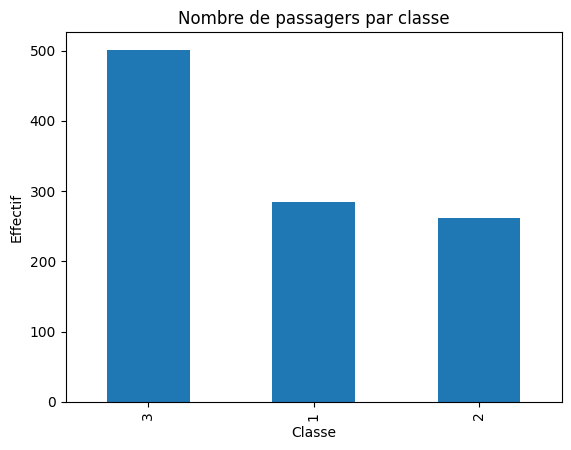

In [ ]:
data['pclass'].value_counts().plot.bar()
plt.title('Nombre de passagers par classe')
plt.xlabel('Classe')
plt.ylabel('Effectif')
plt.show()

Ces graphiques restent des figures Matplotlib. Toutes les commandes vues dans
les notebooks précédents s'appliquent : `title`, `xlabel`, `figsize`, `savefig`.

`plot.bar()` est simplement un raccourci qui évite d'écrire le `plt.bar` à la
main.

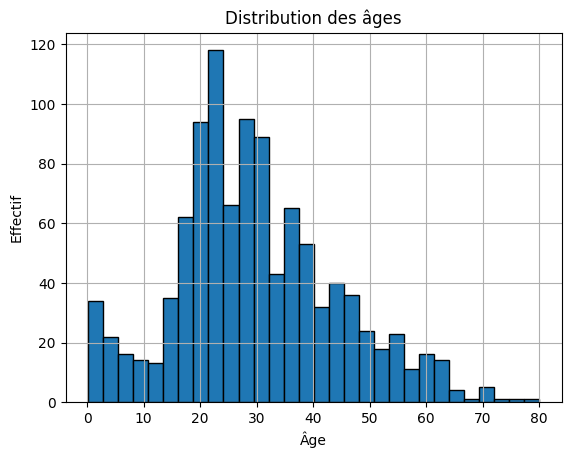

In [ ]:
data['age'].hist(bins=30, edgecolor='black')
plt.title('Distribution des âges')
plt.xlabel('Âge')
plt.ylabel('Effectif')
plt.show()

La distribution est asymétrique, avec un pic vers 20-30 ans et une petite bosse
chez les tout jeunes enfants.

Rappel du notebook Matplotlib : le nombre de `bins` change ce qu'on croit voir.
Essaie avec 10, puis avec 80.

### Croiser deux variables catégorielles

In [ ]:
pd.crosstab(data['sex'], data['pclass'])

pclass,1,2,3
sex,,,
female,133,103,152
male,151,158,349


`crosstab` compte les effectifs pour chaque combinaison. On voit ici que les
hommes sont majoritaires dans toutes les classes, et particulièrement en
troisième.

Avec `normalize`, on obtient des proportions plutôt que des effectifs, ce qui
est souvent plus parlant.

In [ ]:
pd.crosstab(data['sex'], data['survived'], normalize='index').round(3)

survived,0,1
sex,,
female,0.247,0.753
male,0.795,0.205


La ligne des femmes et celle des hommes n'ont rien à voir. C'est le fait
principal de ce jeu de données, et il apparaît en une ligne de code.

## 4. groupby : la fonction centrale

`groupby` découpe le tableau en groupes selon une ou plusieurs colonnes, puis
applique un calcul à chaque groupe. C'est l'outil le plus utilisé de Pandas.

In [ ]:
data.groupby(['sex', 'pclass']).mean(numeric_only=True)

survived        age
sex    pclass                     
female 1       0.962406  37.037594
       2       0.893204  27.499191
       3       0.473684  22.185307
male   1       0.350993  41.029250
       2       0.145570  30.815401
       3       0.169054  25.962273

Le `numeric_only=True` est nécessaire dès que le tableau contient du texte.
Sans lui, Pandas essaie de calculer la moyenne de la colonne `name` et lève un
`TypeError: agg function failed [how->mean,dtype->object]`, avec une liste de
noms de passagers dans le message d'erreur.

Dans les anciennes versions, ces colonnes étaient ignorées silencieusement. Le
changement est volontaire : mieux vaut une erreur qu'une colonne qui disparaît
sans qu'on s'en aperçoive.

### Se concentrer sur la survie

La moyenne d'une colonne de 0 et de 1 est exactement la proportion de 1. La
moyenne de `survived` est donc le taux de survie.

In [ ]:
survie = data.groupby(['sex', 'pclass'])['survived'].mean()
print(survie.round(3))

sex     pclass
female  1         0.962
        2         0.893
        3         0.474
male    1         0.351
        2         0.146
        3         0.169
Name: survived, dtype: float64


Les chiffres parlent d'eux-mêmes. Une femme de première classe avait une chance
de survie proche de la certitude ; un homme de troisième classe, presque nulle.
L'écart entre ces deux extrêmes dépasse largement tout ce qu'un modèle
sophistiqué pourrait ajouter.

C'est la leçon de méthode : un `groupby` bien choisi révèle souvent l'essentiel
avant qu'on ait entraîné quoi que ce soit.

### Le visualiser

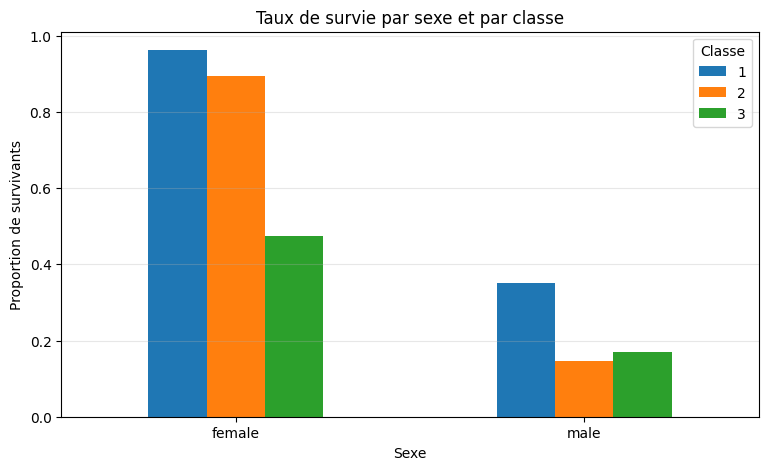

In [ ]:
survie.unstack().plot.bar(figsize=(9, 5))
plt.title('Taux de survie par sexe et par classe')
plt.ylabel('Proportion de survivants')
plt.xlabel('Sexe')
plt.legend(title='Classe')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

`unstack()` transforme le résultat en tableau à deux entrées, avec le sexe en
lignes et la classe en colonnes. C'est ce format que `plot.bar` attend pour
produire des barres groupées.

Sans `unstack`, on obtiendrait six barres alignées les unes derrière les autres,
beaucoup moins lisibles.

### D'autres calculs sur les groupes

In [ ]:
resume = data.groupby(['sex', 'pclass']).agg(effectif=('survived', 'size'),survivants=('survived', 'sum'), taux=('survived', 'mean'),age_median=('age', 'median'),)

print(resume.round(2))

               effectif  survivants  taux  age_median
sex    pclass                                        
female 1            133         128  0.96        36.0
       2            103          92  0.89        28.0
       3            152          72  0.47        22.0
male   1            151          53  0.35        42.0
       2            158          23  0.15        29.5
       3            349          59  0.17        25.0


`agg` permet de demander plusieurs statistiques d'un coup, en nommant chaque
colonne du résultat. La syntaxe est `nom_voulu=('colonne', 'fonction')`.

La colonne `effectif` est importante. Un taux de survie calculé sur six
personnes n'a pas la même valeur qu'un taux calculé sur trois cents, et cette
nuance disparaît si on ne regarde que les moyennes.

## 5. loc et iloc : atteindre une ligne précise

C'est la source de confusion numéro un chez les débutants en Pandas. La
distinction est pourtant simple.

| | Ce qu'il indexe | Borne haute |
|---|---|---|
| `loc` | les **étiquettes** de l'index | **incluse** |
| `iloc` | les **positions**, de 0 à n-1 | **exclue** |

Tant que l'index est numérique, les deux se ressemblent et la différence passe
inaperçue. Elle devient évidente dès qu'on met du texte en index.

In [ ]:
print('Index actuel :', data.index[:5].tolist())
print('Type :', data.index.dtype)

Index actuel : [0, 1, 2, 3, 4]
Type : int64


In [ ]:
# Index numérique : les deux se ressemblent, mais pas tout à fait
print(data.loc[0:2, ['age', 'sex']]) # 3 lignes : 0, 1, 2
print(data.iloc[0:2][['age', 'sex']]) # 2 lignes : 0, 1

       age     sex
0  29.0000  female
1   0.9167    male
2   2.0000  female
       age     sex
0  29.0000  female
1   0.9167    male


Trois lignes contre deux, pour des chiffres identiques. C'est la différence de
borne haute, et elle surprend systématiquement la première fois.

### Mettre les noms en index

In [ ]:
data = data.set_index('name')
data.head(3)

,pclass,survived,sex,age
name,,,,
"Allen, Miss. Elisabeth Walton",1,1,female,29.0000
"Allison, Master. Hudson Trevor",1,1,male,0.9167
"Allison, Miss. Helen Loraine",1,0,female,2.0000


L'index contient désormais les noms des passagers. `loc` peut donc les utiliser
directement, ce qui est bien plus expressif qu'un numéro de ligne.

On peut écrire le nom en clair, par exemple
`data.loc['Allen, Miss. Elisabeth Walton']`. Les cellules ci-dessous passent par
`data.index[0]` pour rester valables quel que soit le fichier chargé.

In [ ]:
premier = data.index[0] # le nom du premier passager
print('Nom :', premier)
print()
print(data.loc[premier])

Nom : Allen, Miss. Elisabeth Walton

pclass           1
survived         1
sex         female
age           29.0
Name: Allen, Miss. Elisabeth Walton, dtype: object


In [ ]:
# Une tranche de noms : la borne haute est INCLUSE
troisieme = data.index[2]
data.loc[premier:troisieme, 'age']

,age
name,
"Allen, Miss. Elisabeth Walton",29.0000
"Allison, Master. Hudson Trevor",0.9167
"Allison, Miss. Helen Loraine",2.0000


### Ce qui ne marche plus

Avec un index textuel, `loc` ne comprend plus les entiers.

In [ ]:
try:
    data.loc[0:2, ['age', 'sex']]
except TypeError as e:
    print('TypeError :', str(e)[:120])

TypeError : cannot do slice indexing on Index with these indexers [0] of type int


Le message est explicite : impossible de découper un index de ce type avec des
entiers. La solution est `iloc`, qui travaille toujours par position quel que
soit l'index.

In [ ]:
data.iloc[0:3][['age', 'sex']]

,age,sex
name,,
"Allen, Miss. Elisabeth Walton",29.0000,female
"Allison, Master. Hudson Trevor",0.9167,male
"Allison, Miss. Helen Loraine",2.0000,female


Et pour revenir en arrière, `reset_index` remet `name` en colonne et restaure un
index numérique.

```python
data = data.reset_index()
```

### Faut-il vraiment un index textuel ?

Mettre les noms en index a du sens si on cherche souvent un passager précis.
Sinon, l'index numérique par défaut est plus simple et évite ces frictions. Le
`set_index` est ici une démonstration, pas une obligation.

## 6. Filtrer avec un masque booléen

Une comparaison sur une colonne produit une série de `True` et de `False`, un par
ligne. C'est le même mécanisme que les masques NumPy, appliqué à un DataFrame.

In [ ]:
mineurs = data['age'] < 18

print(type(mineurs))
print(mineurs.head())
print('Nombre de mineurs :', mineurs.sum())

<class 'pandas.core.series.Series'>
name
Allen, Miss. Elisabeth Walton                      False
Allison, Master. Hudson Trevor                      True
Allison, Miss. Helen Loraine                        True
Allison, Mr. Hudson Joshua Creighton               False
Allison, Mrs. Hudson J C (Bessie Waldo Daniels)    False
Name: age, dtype: bool
Nombre de mineurs : 154


Passer ce masque entre crochets ne garde que les lignes où la condition est
vraie.

In [ ]:
enfants = data[data['age'] < 18]

print('Forme :', enfants.shape)
enfants.head()

Forme : (154, 4)


,pclass,survived,sex,age
name,,,,
"Allison, Master. Hudson Trevor",1,1,male,0.9167
"Allison, Miss. Helen Loraine",1,0,female,2.0000
"Carrau, Mr. Jose Pedro",1,0,male,17.0000
"Carter, Master. William Thornton II",1,1,male,11.0000
"Carter, Miss. Lucile Polk",1,1,female,14.0000


In [ ]:
enfants['pclass'].value_counts()

,count
pclass,
3,106
2,33
1,15


In [ ]:
enfants.groupby(['sex', 'pclass'])['survived'].agg(['size', 'mean']).round(3)

size   mean
sex    pclass             
female 1          8  0.875
       2         18  1.000
       3         46  0.543
male   1          7  0.857
       2         15  0.733
       3         60  0.233

Chez les enfants, l'écart entre garçons et filles s'estompe nettement par
rapport aux adultes, mais l'écart entre classes reste énorme. La consigne
« les femmes et les enfants d'abord » a manifestement mieux fonctionné en
première classe.

Attention toutefois : la colonne `size` montre que certains groupes ne comptent
qu'une poignée d'enfants. Un taux de survie sur cinq personnes ne veut pas dire
grand-chose, et c'est exactement pour ça qu'il faut toujours afficher les
effectifs à côté des moyennes.

### Combiner plusieurs conditions

Pandas utilise `&` pour « et », `|` pour « ou », et exige des parenthèses autour
de chaque condition.

In [ ]:
selection = data[(data['age'] < 18) & (data['pclass'] == 3)]
print('Enfants de troisième classe :', len(selection))
print('Taux de survie :', round(selection['survived'].mean(), 3))

Enfants de troisième classe : 106
Taux de survie : 0.368


Les parenthèses ne sont pas facultatives. Sans elles, Python applique `&` avant
la comparaison et lève une erreur peu explicite.

Et il faut bien `&`, pas `and`. Le mot-clé Python travaille sur une seule valeur
booléenne, alors qu'ici on compare deux séries entières, élément par élément.

## 7. Mémo

### Les fonctions du notebook

| Besoin | Fonction |
|---|---|
| Charger un Excel | `pd.read_excel` |
| Voir la structure | `.shape`, `.columns`, `.dtypes`, `.head()` |
| Statistiques rapides | `.describe()` |
| Compter les manquants | `.isna().sum()` |
| Supprimer des colonnes | `.drop(columns=[...])` |
| Supprimer les lignes incomplètes | `.dropna()` |
| Compter les valeurs | `.value_counts()` |
| Croiser deux variables | `pd.crosstab` |
| Grouper et calculer | `.groupby(...).mean()` ou `.agg(...)` |
| Sélectionner par étiquette | `.loc` |
| Sélectionner par position | `.iloc` |
| Filtrer | `data[data['col'] < seuil]` |

### Les erreurs rencontrées

| Message | Cause | Solution |
|---|---|---|
| `not found in axis` | `drop` sans `axis=1` | `drop(columns=[...])` |
| `agg function failed [how->mean...]` | moyenne sur du texte | `mean(numeric_only=True)` |
| `None of ['name'] are in the columns` | colonne déjà supprimée | recharger, ou revoir l'ordre |
| `cannot do slice indexing` | `loc` avec des entiers sur index texte | utiliser `iloc` |

### L'erreur silencieuse

Celle-ci ne lève aucun message et fausse tous les calculs suivants : un `dropna`
appliqué à des valeurs manquantes qui ne manquent pas au hasard. Ici, il fait
grimper le taux de survie de plusieurs points.

Le réflexe : avant de supprimer, comparer les lignes complètes aux lignes
incomplètes. Si elles diffèrent, la suppression biaise.

## 8. Exercices

**Exercice 1**

Compare trois traitements des âges manquants : suppression, remplacement par la
médiane globale, et remplacement par la médiane du groupe sexe-classe. Pour
chacun, calcule le taux de survie global et la distribution des âges. Lequel
déforme le moins les données, et pourquoi ?

**Exercice 2**

Découpe les âges en tranches avec `pd.cut`, puis calcule le taux de survie par
tranche d'âge et par sexe. Trace le résultat. L'expression « les femmes et les
enfants d'abord » est-elle vérifiée par les chiffres ?

**Exercice 3**

Crée une colonne `titre` à partir des noms de passagers Mr, Mrs, Miss, Master
et les autres, puis étudie le taux de survie par titre. Le titre apporte-t-il
une information que le sexe et l'âge ne donnent pas déjà ? La méthode
`.str.extract()` avec une expression régulière fait le travail.

## Pour continuer

Ce notebook ne couvre qu'une partie de Pandas. Trois sujets méritent la suite :
la fusion de plusieurs tableaux avec `merge` et `concat`, les séries temporelles
avec les index de dates, et les tableaux croisés dynamiques avec `pivot_table`.

Et pour le machine learning proprement dit, l'étape suivante est de convertir le
DataFrame en tableau NumPy avec `.values`, puis de passer à scikit-learn. Les
variables textuelles comme `sex` devront alors être encodées en nombres.

In [ ]:
# Exercice 1

In [ ]:
# Sur Colab, pour envoyer le fichier depuis l'ordinateur :
from google.colab import files
files.upload()

data = pd.read_excel('titanic3.xls')

Saving titanic3.xls to titanic3 (1).xls


In [ ]:
data = pd.read_excel('titanic3.xls')
data = data.drop(columns=['sibsp', 'parch', 'ticket', 'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'])

In [ ]:
# Suppression
suppression = data.dropna(subset=['age'])

# Médiane globale
mediane_globale = data.copy() # copy() : on ne touche pas à data
mediane_globale['age'] = mediane_globale['age'].fillna(mediane_globale['age'].median())

# Médiane par groupe sexe-classe
mediane_groupe = data.copy()
mediane_groupe['age'] = (mediane_groupe.groupby(['sex', 'pclass'])['age'].transform(lambda s: s.fillna(s.median())))

In [ ]:
resultats = pd.DataFrame({
    'lignes': [len(suppression), len(mediane_globale), len(mediane_groupe)],
    'survie': [suppression['survived'].mean(), mediane_globale['survived'].mean(), mediane_groupe['survived'].mean()],
    'age_moyen': [suppression['age'].mean(), mediane_globale['age'].mean(), mediane_groupe['age'].mean()],
    'age_ecart_type': [suppression['age'].std(), mediane_globale['age'].std(), mediane_groupe['age'].std()],}, index=['suppression', 'médiane globale', 'médiane par groupe'])

print(resultats.round(3))
print('Survie réelle, toutes lignes :', round(data['survived'].mean(), 4))

                    lignes  survie  age_moyen  age_ecart_type
suppression           1046   0.408     29.881          14.413
médiane globale       1309   0.382     29.503          12.905
médiane par groupe    1309   0.382     29.261          13.218
Survie réelle, toutes lignes : 0.382


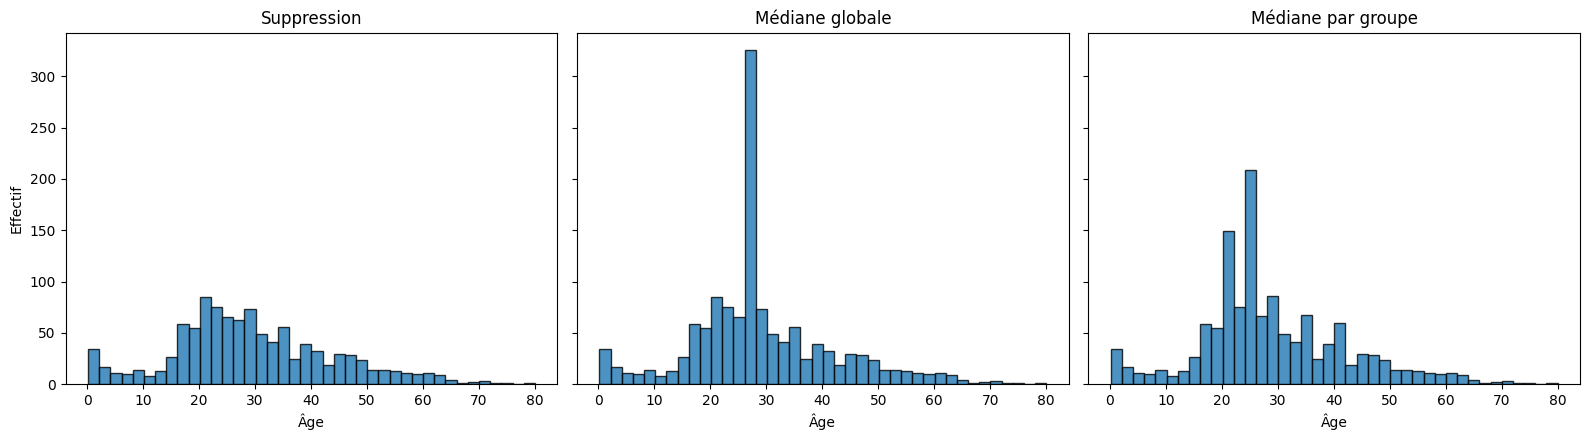

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)

for i, (titre, jeu) in enumerate([('Suppression', suppression), ('Médiane globale', mediane_globale), ('Médiane par groupe', mediane_groupe)]):
    ax[i].hist(jeu['age'], bins=40, edgecolor='black', alpha=0.8)
    ax[i].set_title(titre)
    ax[i].set_xlabel('Âge')

ax[0].set_ylabel('Effectif')
plt.tight_layout()
plt.show()

In [ ]:
final = mediane_groupe.copy()
final['age_manquait'] = data['age'].isna()
print(final.groupby('age_manquait')['survived'].agg(['size', 'mean']).round(3))

              size   mean
age_manquait             
False         1046  0.408
True           263  0.278


In [ ]:
# Exercice 2

In [ ]:
data = data.dropna(subset=['age'])

tranches = [0, 12, 18, 30, 50, 100]
noms = ['0-12 ans', '13-18 ans', '19-30 ans', '31-50 ans', 'plus de 50']

data['tranche'] = pd.cut(data['age'], bins=tranches, labels=noms)

resume = (data.groupby(['tranche', 'sex'], observed=True)['survived'].agg(['size', 'mean']).round(3))
resume.columns = ['effectif', 'taux_survie']
print(resume)

                   effectif  taux_survie
tranche    sex                          
0-12 ans   female        44        0.614
           male          50        0.540
13-18 ans  female        48        0.750
           male          51        0.098
19-30 ans  female       143        0.720
           male         273        0.183
31-50 ans  female       121        0.802
           male         221        0.199
plus de 50 female        32        0.906
           male          63        0.143


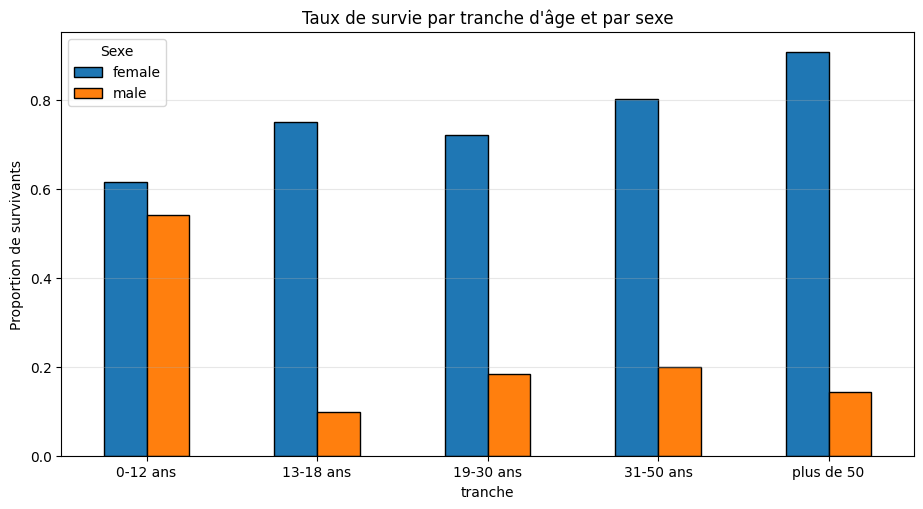

In [ ]:
resume['taux_survie'].unstack().plot.bar(figsize=(11, 5.5), edgecolor='black')
plt.title("Taux de survie par tranche d'âge et par sexe")
plt.ylabel('Proportion de survivants')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Sexe')
plt.show()

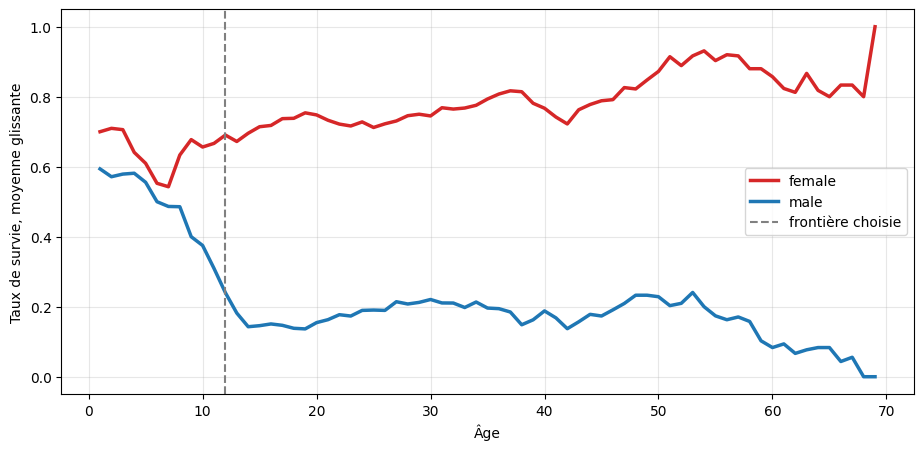

In [ ]:
plt.figure(figsize=(11, 5))

for sexe, couleur in [('female', 'tab:red'), ('male', 'tab:blue')]:
    sous = data[data['sex'] == sexe]
    ages = np.arange(1, 70)
    taux = [sous[(sous['age'] >= a - 5) & (sous['age'] <= a + 5)]['survived'].mean() for a in ages]
    plt.plot(ages, taux, lw=2.5, color=couleur, label=sexe)

plt.axvline(12, color='gray', ls='--', label='frontière choisie')
plt.xlabel('Âge')
plt.ylabel('Taux de survie, moyenne glissante')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Exercice 3

In [ ]:
# Sur Colab, pour envoyer le fichier depuis l'ordinateur :
from google.colab import files
files.upload()

data = pd.read_excel('titanic3.xls')

Saving titanic3.xls to titanic3 (2).xls


In [ ]:
data['titre'] = data['name'].str.extract(r' ([A-Za-z]+)\.')
print(data['titre'].value_counts())

titre
Mr          757
Miss        260
Mrs         197
Master       61
Dr            8
Rev           8
Col           4
Major         2
Mlle          2
Ms            2
Lady          1
Capt          1
Mme           1
Sir           1
Jonkheer      1
Dona          1
Don           1
Countess      1
Name: count, dtype: int64


In [ ]:
frequents = ['Mr', 'Mrs', 'Miss', 'Master']
data['titre_groupe'] = data['titre'].where(data['titre'].isin(frequents), 'Autre')

resume = (data.groupby('titre_groupe')['survived'].agg(['size', 'mean']).round(3).sort_values('mean', ascending=False))
resume.columns = ['effectif', 'taux_survie']
print(resume)

              effectif  taux_survie
titre_groupe                       
Mrs                197        0.787
Miss               260        0.677
Master              61        0.508
Autre               34        0.441
Mr                 757        0.162


In [ ]:
print(pd.crosstab(data['titre_groupe'], data['sex']))
print(data.groupby('titre_groupe')['age'].agg(['median', 'count']).round(1))

sex           female  male
titre_groupe              
Autre              9    25
Master             0    61
Miss             260     0
Mr                 0   757
Mrs              197     0
              median  count
titre_groupe               
Autre           44.5     32
Master           4.0     53
Miss            22.0    210
Mr              29.0    581
Mrs             35.5    170


In [ ]:
sans_age = data[data['age'].isna()]
print(f'{len(sans_age)} passagers sans âge')
print(sans_age.groupby('titre_groupe')['survived'].agg(['size', 'mean']).round(3))

263 passagers sans âge
              size   mean
titre_groupe             
Autre            2  0.000
Master           8  0.375
Miss            50  0.600
Mr             176  0.131
Mrs             27  0.630


In [ ]:
data['age_impute'] = (data.groupby('titre_groupe')['age'].transform(lambda s: s.fillna(s.median())))

print(f"Écart-type avant : {data['age'].std():.2f}, après : {data['age_impute'].std():.2f}")

Écart-type avant : 14.41, après : 13.17


In [ ]:
femmes_adultes = data[(data['sex'] == 'female') & (data['age'] >= 18)]
print(femmes_adultes.groupby('titre_groupe')['survived'].agg(['size', 'mean']).round(3))

              size   mean
titre_groupe             
Autre            8  1.000
Miss           143  0.706
Mrs            165  0.806
